In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle 
import pandas as pd
import seaborn as sns
from astropy.io import fits
import os


# GLS Periodogram plot

In [2]:
# Import data RV ESPRESSO
# ===============================

data_dir = "/home/ymascolo/Desktop/github/datasets" # path datsets

df_all = pd.read_csv(os.path.join(data_dir,"ESPRESSO/RV_data.txt"), sep='\s+')

df = df_all.dropna(subset=['rv_bart', 'rv_bart_err'])

t = df['bjd'] - 2457000

rv = df['rv_bart']-np.nanmean(df['rv_bart'])
rv_err = df['rv_bart_err']

fwhm = df['fwhm_esp']-np.nanmean(df['fwhm_esp']) 
fwhm_err = df['fwhm_esp_err']

bis = df['bis'] - np.nanmean(df['bis'])
bis_err = df['bis_err']

asym = df['asym'] - np.nanmean(df['asym'])
asym_err = df['asym_err']

s_index = df['s'] - np.nanmean(df['s'])
s_index_err = df['s_err']

ha = df['ha'] - np.nanmean(df['ha'])
ha_err = df['ha_err']

na = df['na'] - np.nanmean(df['na'])
na_err = df['na_err']

ca = df['ca'] - np.nanmean(df['ca'])
ca_err = df['ca_err']



In [3]:
# TESS datasets
# ================================


# -------Load TESS sectors function------------
def tess_sector(filename):
    
    hdul = fits.open(filename)
    
    if "LIGHTCURVE" in hdul[1].name:
        hdu = hdul[1]
    else:
        raise ValueError("Light curve HDU not found")
    
    data = hdu.data
    hdr  = hdu.header

    quality_mask = (data["QUALITY"] == 0)
    
    # time, sap flux masked 
    time = data["TIME"][quality_mask] # BTJD = BJD -2457000
    sap_flux = data["SAP_FLUX"][quality_mask]
    
    # crowding correction and nan mask
    crowdsap = hdr["CROWDSAP"]
    flux_corr = sap_flux / crowdsap
    nanmask = np.isnan(time) + np.isnan(flux_corr) 
    time = time[~nanmask]
    flux_corr = flux_corr[~nanmask]

    # normalization
    norm = np.nanmedian(flux_corr)
    flux = flux_corr / norm
    # error
    sigma = np.median(np.abs(np.diff(flux_corr)))
    flux_err = np.full_like(flux, 1.4826 * sigma) / norm 

    return time, flux, flux_err



# --------TESS datasets---------

sector_files = [
    os.path.join(data_dir,"TESS/tess2018292075959-s0004-0000000337217173-0124-s_lc.fits"),
    os.path.join(data_dir,"TESS/tess2020294194027-s0031-0000000337217173-0198-s_lc.fits"),
    os.path.join(data_dir,"TESS/tess2021232031932-s0042-0000000337217173-0213-s_lc.fits"),
    os.path.join(data_dir, "TESS/tess2023263165758-s0070-0000000337217173-0265-s_lc.fits"),
    os.path.join(data_dir, "TESS/tess2023289093419-s0071-0000000337217173-0266-s_lc.fits")
]

labels = [4,31,42,70,71]
t_all = []
flux_all = []
flux_err_all = []
tess_data = []

for  i, f in enumerate(sector_files):
    time_tess, flux_tess, flux_err_tess = tess_sector(f)

    tess_data.append({
        "sector": labels[i],
        "time": time_tess,
        "flux": flux_tess,
        "err": flux_err_tess
    })

    t_all.append(time_tess)
    flux_all.append(flux_tess)
    flux_err_all.append(flux_err_tess)

#concatenate all datasets 
t_all = np.concatenate(t_all)
flux_all = np.concatenate(flux_all)
flux_err_all = np.concatenate(flux_err_all)


In [4]:
# ======================
# Lomb-Scargle TESS window
# ======================
max_period_tess = (t_all.max() - t_all.min())
min_period_tess = 1

ls_all_tess = LombScargle(t_all, flux_all, flux_err_all, normalization='standard')
freq_all_tess, power_all_tess = ls_all_tess.autopower(
    minimum_frequency=1/max_period_tess,
    maximum_frequency=1/min_period_tess,
    samples_per_peak=20
)
period_all_tess = 1/freq_all_tess

# ======================
# Lomb-Scargle RV window
# ======================

baseline = t.max() - t.min()
min_period = 1
max_period = baseline

window_signal_rv = np.ones_like(t)
ls_window_rv = LombScargle(t, window_signal_rv, center_data=False, fit_mean=False)

freq_window_rv, power_window_rv = ls_window_rv.autopower(
    minimum_frequency=1/max_period,
    maximum_frequency=1/min_period,
    samples_per_peak=20
)

period_window_rv = 1 / freq_window_rv

In [5]:
# ========================================
# Lomb-Scargle RV and stellar indicators
# ========================================

data_dict = {
    "rv": (rv, rv_err),
    "fwhm": (fwhm, fwhm_err),
    "bis": (bis, bis_err),
    "asym": (asym, asym_err),
    "s_index": (s_index, s_index_err),
    "ha": (ha, ha_err),
    "na": (na, na_err),
    "ca": (ca, ca_err),
}

results = {}

for name, (y, yerr) in data_dict.items():

    # Lomb-Scargle
    ls = LombScargle(t, y, yerr)
    freq, power = ls.autopower(
        minimum_frequency=1/max_period,
        maximum_frequency=1/min_period,
        samples_per_peak=20
    )

    period = 1 / freq

    results[name] = {
        "ls": ls,
        "freq": freq,
        "power": power,
        "period": period
    }




findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


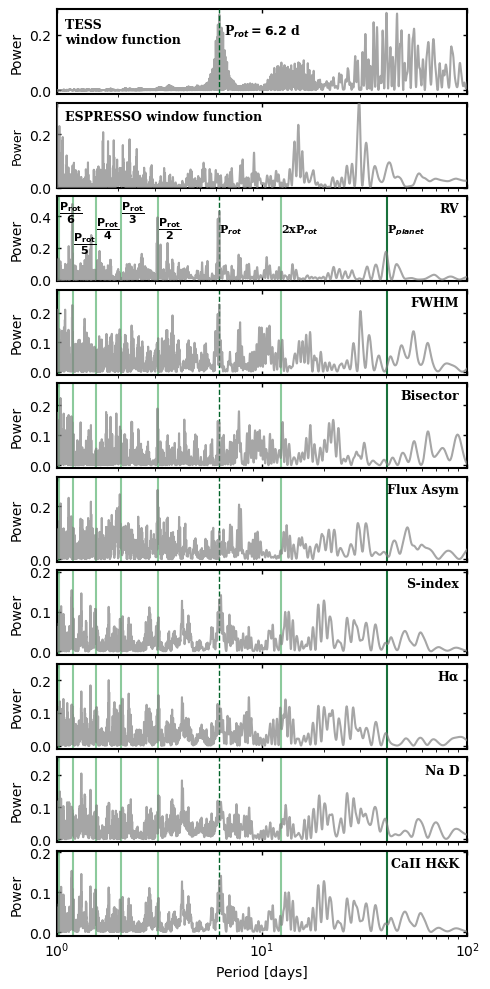

In [6]:
# Plot
#===============

colors = sns.color_palette("Greens", 10)  
series = [
    ("RV", results['rv']['period'], results['rv']['power'], results['rv']['ls']), # Added LS object
    ("FWHM", results['fwhm']['period'], results['fwhm']['power'], results['fwhm']['ls']),
    ("Bisector", results['bis']['period'], results['bis']['power'], results['bis']['ls']),
    ("Flux Asym", results['asym']['period'], results['asym']['power'], results['asym']['ls']),
    ("S-index", results['s_index']['period'], results['s_index']['power'], results['s_index']['ls']),
    ("Hα", results['ha']['period'], results['ha']['power'], results['ha']['ls']),
    ("Na D", results['na']['period'], results['na']['power'], results['na']['ls']),
    ("CaII H&K", results['ca']['period'], results['ca']['power'], results['ca']['ls']),
]

fap_levels = [0.1, 0.01, 0.001]
fap_labels = ['10%', '1%', '0.1%']

# Create figure with len(series) + 1 (for TESS)
fig, ax = plt.subplots(len(series) + 2, 1, figsize=(5, 10), sharex=True)


plt.rcParams.update({
    "font.size": 10,
    "font.family": "serif",
    'font.weight': 'bold',        # Bold standard text
    'axes.labelweight': 'bold',   # Bold X and Y labels
    'axes.titleweight': 'bold',   # Bold Title
    'figure.titleweight': 'bold',  # Bold Figure title
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    'mathtext.fontset': 'custom',
    'mathtext.bf': 'sans:bold',
    'mathtext.rm': 'sans',
})

# ============================
# PANEL 0: TESS Periodogram
# ============================

ax[0].plot(period_all_tess, power_all_tess, 'grey', alpha=0.7, zorder=3)
ax[0].axvline(6.2, color=colors[9], linestyle='--', zorder=3, lw=1)
ax[0].set_ylabel("Power", fontsize=10)
ax[0].text(0.02, 0.6, "TESS \nwindow function", fontsize=9, transform=ax[0].transAxes, fontweight='bold')
ax[0].annotate("P$_{rot}=6.2$ d", xy=(6.2, 0.2), xytext=(6.2+0.3, 0.2), fontsize=9)

for side in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[side].set_linewidth(1.5)
    ax[0].spines[side].set_edgecolor('black')
ax[0].grid(False)
ax[0].set_facecolor('white')
ax[0].tick_params(axis='both', which='major', labelsize=10,
               width=1, length=3, color='black', direction='in', top=True, right=True)

# ============================
# PANEL 1: RV Periodogram
# ============================

ax[1].plot(period_window_rv, power_window_rv, 'grey', alpha=0.7, zorder=3)
ax[1].set_ylabel("Power", fontsize=9)
ax[1].text(0.02, 0.8, "ESPRESSO window function", fontsize=9, transform=ax[1].transAxes, fontweight='bold')
ax[1].set_ylim(0,0.32)


for side in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[side].set_linewidth(1.5)
    ax[1].spines[side].set_edgecolor('black')
ax[1].grid(False)
ax[1].set_facecolor('white')
ax[1].tick_params(axis='both', which='major', labelsize=10,
               width=1, length=3, color='black', direction='in', top=True, right=True)

# ============================
# PANELS 1 to N: Indicators
# ============================
for i, (label, period, power, ls_obj) in enumerate(series):
    idx = i + 2  # Shift by 1 to account for TESS panel
    
    ax[idx].plot(period, power, 'grey', alpha=0.7, zorder=3, label='s-BART pipeline')
    ax[idx].set_ylim(-0.01, np.max(power)+0.05)
    ax[idx].set_xlim(1, 100)
    ax[idx].set_xscale('log')
    ax[idx].set_ylabel('Power', fontsize=10)

    info_text = f"{label}"
    
    ax[idx].text(0.98, 0.85, info_text, transform=ax[idx].transAxes, fontsize=9, weight='bold', va='center', ha='right')

    # Vertical lines for context
    ax[idx].axvline(6.2, color=colors[9], linestyle='--', lw=1)
    ax[idx].axvline(12.4, color=colors[6],  alpha=0.6)
    ax[idx].axvline(1.55, color=colors[6], alpha=0.6) # Harmonic 4
    ax[idx].axvline(1.2, color=colors[6], alpha=0.6) # Harmonic 5 
    ax[idx].axvline(3.1, color=colors[6], alpha=0.6) # Harmonic 2
    ax[idx].axvline(2.07, color=colors[6], alpha=0.6) # Harmonic 3
    ax[idx].axvline(1.03, color=colors[6], alpha=0.6) # Harmonic 6
    ax[idx].axvline(40.4, color=colors[9], alpha=0.9, zorder=2, lw=1.5)

    for side in ['top', 'bottom', 'left', 'right']:
        ax[idx].spines[side].set_linewidth(1.5)
        ax[idx].spines[side].set_edgecolor('black')
    ax[idx].grid(False)
    ax[idx].set_facecolor('white')
    ax[idx].tick_params(axis='both', which='major', labelsize=10,
                width=1, length=3, color='black', direction='in', top=True, right=True)


# Specific Annotations on the Indicator panels
ax[2].annotate("P$_{rot}$", xy=(6.2, 0.3), xytext=(6.2, 0.3), fontsize=8)
ax[2].annotate("2xP$_{rot}$", xy=(12.4, 0.3), xytext=(12.4, 0.3), fontsize=8)
ax[2].annotate("P$_{planet}$", xy=(40.4, 0.3), xytext=(40.4, 0.3), fontsize=8)
ax[2].annotate("$\mathrm{\\dfrac{P_{rot}}{2}}$", xy=(3.1, 0.3), xytext=(3.1, 0.3), fontsize=8)
ax[2].annotate("$\mathrm{\\dfrac{P_{rot}}{3}}$", xy=(2.07, 0.4), xytext=(2.07, 0.4), fontsize=8)
ax[2].annotate("$\mathrm{\\dfrac{P_{rot}}{4}}$", xy=(1.55, 0.3), xytext=(1.55, 0.3), fontsize=8)
ax[2].annotate("$\mathrm{\\dfrac{P_{rot}}{5}}$", xy=(1.2, 0.2), xytext=(1.2, 0.2), fontsize=8)
ax[2].annotate("$\mathrm{\\dfrac{P_{rot}}{6}}$", xy=(1.03, 0.4), xytext=(1.03, 0.4), fontsize=8)


plt.xlabel("Period [days]", fontsize=10)
plt.tight_layout()
plt.subplots_adjust(hspace=0.1) # Reduce space between panels
# plt.savefig('periodogram.pdf', dpi=300)
plt.show()